# Exploratory Analysis Notebook – Formulation Alarms

### STEP 1: Imports and Configuration

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import sys
from pathlib import Path

# Add root directory to the path
sys.path.insert(0, str(Path.cwd().parent))

from src.etl_pipeline import ETLPipeline
from src.load.database import DatabaseLoader

# Configure chart styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configure pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

print("✓ Ambiente configurado com sucesso!")

✓ Ambiente configurado com sucesso!


### STEP 2: Load Data from the Database

In [8]:
# Conectar ao banco
db_loader = DatabaseLoader()

# Carregar todos os dados
query = "SELECT * FROM alarm_logs ORDER BY datetime"
df = pd.read_sql(query, db_loader.engine)

print(f"Dataset carregado: {len(df)} registros")
print(f"Período: {df['datetime'].min()} até {df['datetime'].max()}")
print(f"\nColunas disponíveis:\n{df.columns.tolist()}")

INFO - Engine criada: /home/wesley/dev-projects-python/etl-formulation-alarms/database/alarmes_formulacao.db
INFO - Tabelas criadas/verificadas no banco de dados
Dataset carregado: 2281 registros
Período: 2025-10-05 06:41:55.700000 até 2025-11-03 12:32:23.400000

Colunas disponíveis:
['arquivo_origem', 'timestamp', 'datetime', 'pc_id', 'alarm', 'type', 'linha_original', 'created_at']


### STEP 3: Data Overview

In [9]:
print("="*80)
print("VISÃO GERAL DO DATASET")
print("="*80)

# Informações básicas
print("\n1. Informações do DataFrame:")
print(df.info())

print("\n2. Estatísticas descritivas:")
print(df.describe(include='all'))

print("\n3. Primeiras linhas:")
df.head(10)

VISÃO GERAL DO DATASET

1. Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2281 entries, 0 to 2280
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   arquivo_origem  2281 non-null   object
 1   timestamp       2281 non-null   object
 2   datetime        2281 non-null   object
 3   pc_id           2281 non-null   object
 4   alarm           2281 non-null   object
 5   type            2281 non-null   object
 6   linha_original  2281 non-null   object
 7   created_at      2281 non-null   object
dtypes: object(8)
memory usage: 142.7+ KB
None

2. Estatísticas descritivas:
                    arquivo_origem              timestamp  \
count                         2281                   2281   
unique                          30                   2281   
top     2025-10-21_formulation.log  2025-10-05 06:41:55,7   
freq                           108                      1   

                  

,arquivo_origem,timestamp,datetime,pc_id,alarm,type,linha_original,created_at
0,2025-10-05_formulation.log,"2025-10-05 06:41:55,7",2025-10-05 06:41:55.700000,PC510A01,FMSNS01,ACK,"2025-10-05 06:41:55,7 [PC510A01] FMSNS01 ALARM...",2026-02-17 18:07:44.880835
1,2025-10-05_formulation.log,"2025-10-05 06:43:45,9",2025-10-05 06:43:45.900000,PC510A01,FMSNS01,OK,"2025-10-05 06:43:45,9 [PC510A01] FMSNS01 ...",2026-02-17 18:07:44.880835
2,2025-10-05_formulation.log,"2025-10-05 06:46:31,0",2025-10-05 06:46:31.000000,PC520A01,FMTNK02,CFN,"2025-10-05 06:46:31,0 [PC520A01] FMTNK02 ...",2026-02-17 18:07:44.880835
3,2025-10-05_formulation.log,"2025-10-05 06:47:33,4",2025-10-05 06:47:33.400000,PC520A01,FMTNK02,ACK,"2025-10-05 06:47:33,4 [PC520A01] FMTNK02 ALARM...",2026-02-17 18:07:44.880835
4,2025-10-05_formulation.log,"2025-10-05 06:49:39,4",2025-10-05 06:49:39.400000,PC520A01,FMTNK02,OK,"2025-10-05 06:49:39,4 [PC520A01] FMTNK02 ...",2026-02-17 18:07:44.880835
5,2025-10-05_formulation.log,"2025-10-05 06:54:13,1",2025-10-05 06:54:13.100000,PC530A00,FMTNK01,CFN,"2025-10-05 06:54:13,1 [PC530A00] FMTNK01 ...",2026-02-17 18:07:44.880835
6,2025-10-05_formulation.log,"2025-10-05 06:54:55,3",2025-10-05 06:54:55.300000,PC530A00,FMTNK01,ACK,"2025-10-05 06:54:55,3 [PC530A00] FMTNK01 ALARM...",2026-02-17 18:07:44.880835
7,2025-10-05_formulation.log,"2025-10-05 06:57:20,1",2025-10-05 06:57:20.100000,PC530A00,FMTNK01,OK,"2025-10-05 06:57:20,1 [PC530A00] FMTNK01 ...",2026-02-17 18:07:44.880835
8,2025-10-05_formulation.log,"2025-10-05 07:01:25,2",2025-10-05 07:01:25.200000,PC520A00,FMMIX01,CFN,"2025-10-05 07:01:25,2 [PC520A00] FMMIX01 ...",2026-02-17 18:07:44.880835
9,2025-10-05_formulation.log,"2025-10-05 07:01:29,7",2025-10-05 07:01:29.700000,PC520A00,FMMIX01,CFN,"2025-10-05 07:01:29,7 [PC520A00] FMMIX01 ...",2026-02-17 18:07:44.880835


### STEP 4: Unique Values Analysis

In [10]:
print("="*80)
print("ANÁLISE DE VALORES ÚNICOS")
print("="*80)

print(f"\nTotal de arquivos de origem: {df['arquivo_origem'].nunique()}")
print(f"Total de PCs únicos: {df['pc_id'].nunique()}")
print(f"Total de alarmes únicos: {df['alarm'].nunique()}")

print("\n--- Distribuição por Tipo de Alarme ---")
print(df['type'].value_counts())

print("\n--- Top 10 Alarmes Mais Frequentes ---")
print(df['alarm'].value_counts().head(10))

print("\n--- Top 10 PCs com Mais Alarmes ---")
print(df['pc_id'].value_counts().head(10))

ANÁLISE DE VALORES ÚNICOS

Total de arquivos de origem: 30
Total de PCs únicos: 5
Total de alarmes únicos: 20

--- Distribuição por Tipo de Alarme ---
type
CFN    817
ACK    732
OK     732
Name: count, dtype: int64

--- Top 10 Alarmes Mais Frequentes ---
alarm
FMBMP01    146
FMPH001    142
FMFLT01    141
FMTMP01    132
FMTNK01    131
FMMIX01    130
FMVSC01    125
FMAGT01    122
FMSNS02    120
FMCOOL1    116
Name: count, dtype: int64

--- Top 10 PCs com Mais Alarmes ---
pc_id
PC510A01    495
PC530A00    478
PC510A00    453
PC520A01    446
PC520A00    409
Name: count, dtype: int64


### STEP 5: Temporal Analysis

In [11]:
print("="*80)
print("ANÁLISE TEMPORAL")
print("="*80)

# Converter para datetime se necessário
df['datetime'] = pd.to_datetime(df['datetime'])

# Adicionar colunas temporais
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.to_period('M')

print("\n--- Alarmes por Dia ---")
alarms_by_day = df.groupby('date').size()
print(alarms_by_day.describe())

print("\n--- Alarmes por Hora do Dia ---")
alarms_by_hour = df.groupby('hour').size()
print(alarms_by_hour)

ANÁLISE TEMPORAL

--- Alarmes por Dia ---
count     30.000000
mean      76.033333
std       17.529253
min       44.000000
25%       61.250000
50%       79.500000
75%       90.750000
max      108.000000
dtype: float64

--- Alarmes por Hora do Dia ---
hour
6     135
7     341
8     539
9     522
10    434
11    230
12     62
13     18
dtype: int64


### STEP 6: Visualizations – Distribution by Type

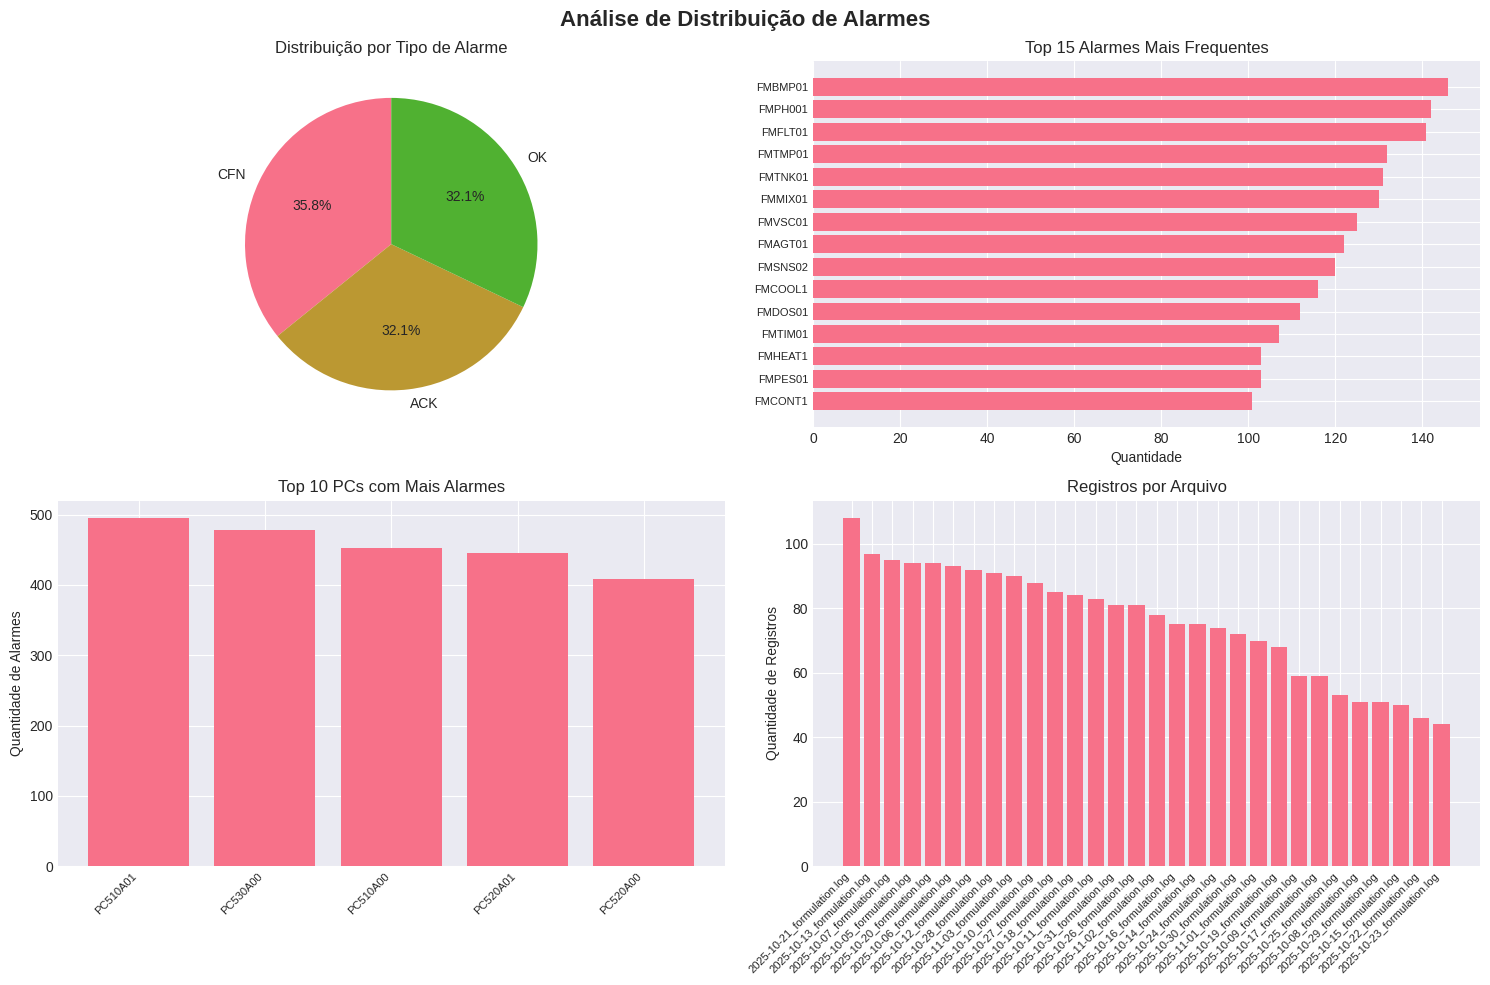

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise de Distribuição de Alarmes', fontsize=16, fontweight='bold')

# 1. Distribuição por Tipo
type_counts = df['type'].value_counts()
axes[0, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title('Distribuição por Tipo de Alarme')

# 2. Top 15 Alarmes
top_alarms = df['alarm'].value_counts().head(15)
axes[0, 1].barh(range(len(top_alarms)), top_alarms.values)
axes[0, 1].set_yticks(range(len(top_alarms)))
axes[0, 1].set_yticklabels(top_alarms.index, fontsize=8)
axes[0, 1].set_xlabel('Quantidade')
axes[0, 1].set_title('Top 15 Alarmes Mais Frequentes')
axes[0, 1].invert_yaxis()

# 3. Top 10 PCs
top_pcs = df['pc_id'].value_counts().head(10)
axes[1, 0].bar(range(len(top_pcs)), top_pcs.values)
axes[1, 0].set_xticks(range(len(top_pcs)))
axes[1, 0].set_xticklabels(top_pcs.index, rotation=45, ha='right', fontsize=8)
axes[1, 0].set_ylabel('Quantidade de Alarmes')
axes[1, 0].set_title('Top 10 PCs com Mais Alarmes')

# 4. Distribuição por Arquivo
file_counts = df['arquivo_origem'].value_counts()
axes[1, 1].bar(range(len(file_counts)), file_counts.values)
axes[1, 1].set_xticks(range(len(file_counts)))
axes[1, 1].set_xticklabels(file_counts.index, rotation=45, ha='right', fontsize=8)
axes[1, 1].set_ylabel('Quantidade de Registros')
axes[1, 1].set_title('Registros por Arquivo')

plt.tight_layout()
plt.show()

### STEP 7: Visualizations – Temporal Analysis

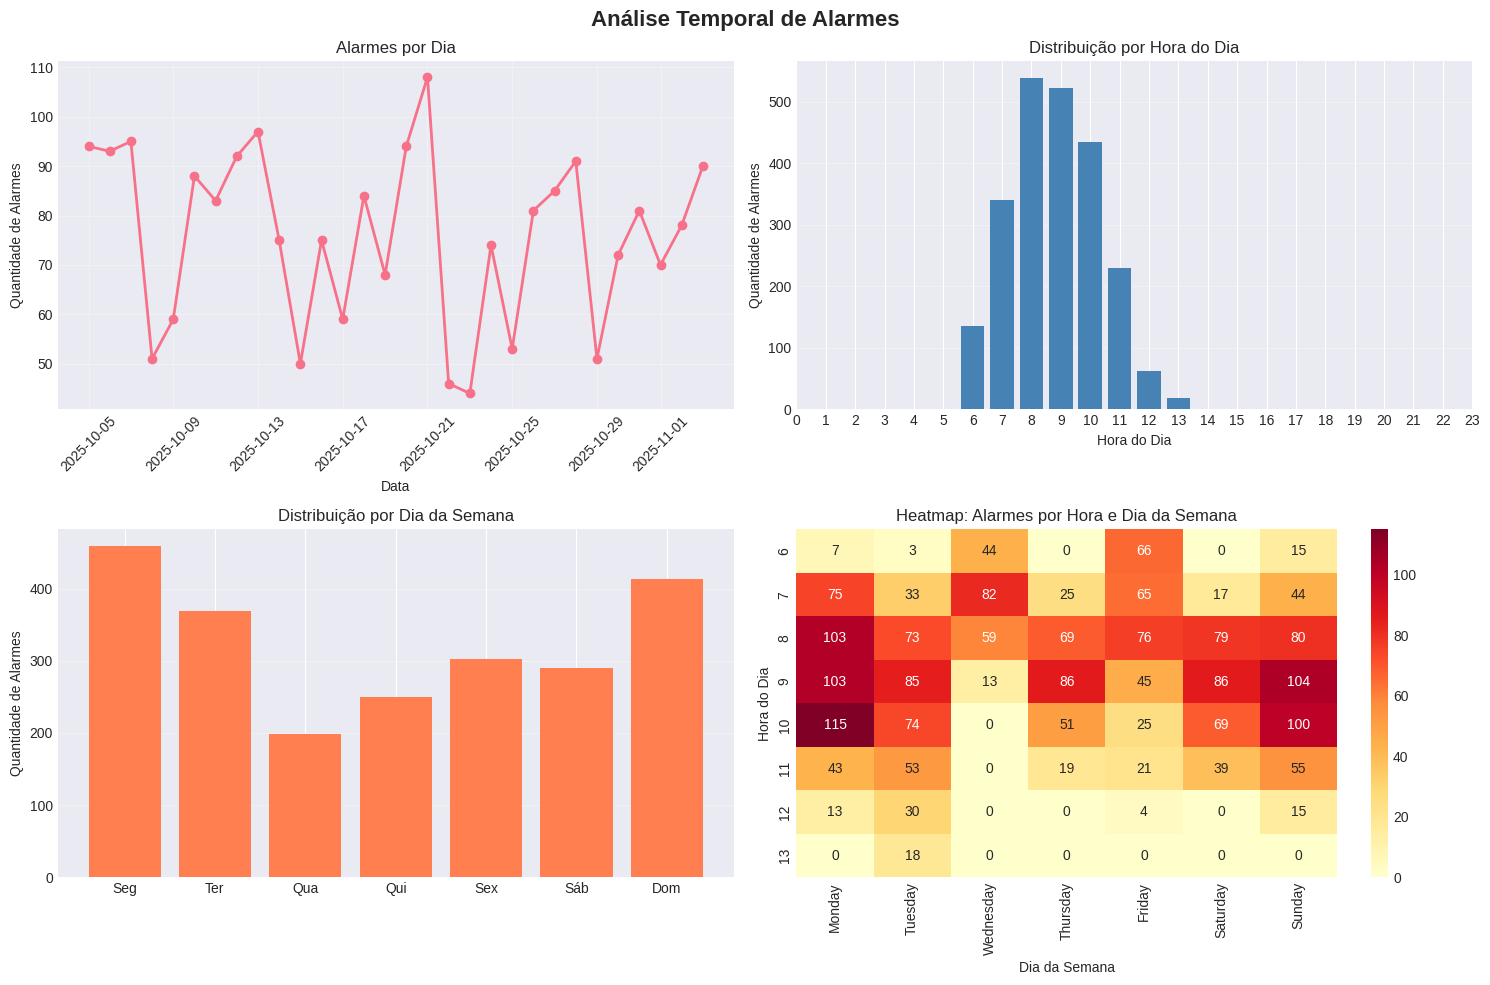

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Análise Temporal de Alarmes', fontsize=16, fontweight='bold')

# 1. Série temporal diária
daily_alarms = df.groupby('date').size()
axes[0, 0].plot(daily_alarms.index, daily_alarms.values, marker='o', linewidth=2)
axes[0, 0].set_xlabel('Data')
axes[0, 0].set_ylabel('Quantidade de Alarmes')
axes[0, 0].set_title('Alarmes por Dia')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Alarmes por hora do dia
hourly_alarms = df.groupby('hour').size()
axes[0, 1].bar(hourly_alarms.index, hourly_alarms.values, color='steelblue')
axes[0, 1].set_xlabel('Hora do Dia')
axes[0, 1].set_ylabel('Quantidade de Alarmes')
axes[0, 1].set_title('Distribuição por Hora do Dia')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Alarmes por dia da semana
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_alarms = df['day_of_week'].value_counts().reindex(dow_order)
axes[1, 0].bar(range(len(dow_alarms)), dow_alarms.values, color='coral')
axes[1, 0].set_xticks(range(len(dow_alarms)))
axes[1, 0].set_xticklabels(['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom'])
axes[1, 0].set_ylabel('Quantidade de Alarmes')
axes[1, 0].set_title('Distribuição por Dia da Semana')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Heatmap hora vs dia da semana
pivot_data = df.pivot_table(
    values='alarm', 
    index='hour', 
    columns='day_of_week', 
    aggfunc='count',
    fill_value=0
)[dow_order]
sns.heatmap(pivot_data, cmap='YlOrRd', annot=True, fmt='g', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap: Alarmes por Hora e Dia da Semana')
axes[1, 1].set_xlabel('Dia da Semana')
axes[1, 1].set_ylabel('Hora do Dia')

plt.tight_layout()
plt.show()

### STEP 8: CFN → ACK → OK Sequence Analysis

In [14]:
print("="*80)
print("ANÁLISE DE SEQUÊNCIAS DE ALARMES")
print("="*80)

# Agrupar por PC e Alarme
grouped = df.sort_values(['pc_id', 'alarm', 'datetime'])

# Analisar sequências completas
sequences = []
for (pc_id, alarm), group in grouped.groupby(['pc_id', 'alarm']):
    types = group['type'].tolist()
    
    # Verificar se há sequência completa CFN -> ACK -> OK
    if 'CFN' in types and 'ACK' in types and 'OK' in types:
        cfn_time = group[group['type'] == 'CFN']['datetime'].iloc[0]
        ack_time = group[group['type'] == 'ACK']['datetime'].iloc[0] if 'ACK' in types else None
        ok_time = group[group['type'] == 'OK']['datetime'].iloc[0]
        
        sequences.append({
            'pc_id': pc_id,
            'alarm': alarm,
            'cfn_time': cfn_time,
            'ack_time': ack_time,
            'ok_time': ok_time,
            'duration_to_ack': (ack_time - cfn_time).total_seconds() / 60 if ack_time else None,
            'duration_to_ok': (ok_time - cfn_time).total_seconds() / 60
        })

df_sequences = pd.DataFrame(sequences)

if not df_sequences.empty:
    print(f"\nEncontradas {len(df_sequences)} sequências completas")
    print("\n--- Estatísticas de Tempo de Resolução (minutos) ---")
    print(df_sequences[['duration_to_ack', 'duration_to_ok']].describe())
    
    print("\n--- Top 10 Alarmes com Maior Tempo de Resolução ---")
    print(df_sequences.nlargest(10, 'duration_to_ok')[['pc_id', 'alarm', 'duration_to_ok']])
else:
    print("\nNenhuma sequência completa encontrada")

ANÁLISE DE SEQUÊNCIAS DE ALARMES

Encontradas 99 sequências completas

--- Estatísticas de Tempo de Resolução (minutos) ---
       duration_to_ack  duration_to_ok
count        99.000000       99.000000
mean       -686.978030     -684.250236
std        2131.293347     2131.272492
min      -11544.881667   -11542.016667
25%           0.301667        2.123333
50%           0.781667        3.216667
75%           1.387500        4.453333
max           1.993333        6.803333

--- Top 10 Alarmes com Maior Tempo de Resolução ---
       pc_id    alarm  duration_to_ok
56  PC520A00  FMTNK01        6.803333
37  PC510A01  FMTNK02        6.531667
53  PC520A00  FMSNS02        6.411667
8   PC510A00  FMMIX01        6.155000
59  PC520A00  FMVSC01        6.030000
60  PC520A01  FMAGT01        6.021667
34  PC510A01  FMTIM01        5.728333
76  PC520A01  FMTNK01        5.678333
27  PC510A01  FMHEAT1        5.648333
35  PC510A01  FMTMP01        5.571667


### STEP 9: Export Analyses

In [15]:
print("="*80)
print("EXPORTANDO ANÁLISES")
print("="*80)

# Criar diretório de saída
output_dir = Path('../database/analysis_output')
output_dir.mkdir(exist_ok=True)

# 1. Resumo estatístico
summary = {
    'total_records': len(df),
    'unique_pcs': df['pc_id'].nunique(),
    'unique_alarms': df['alarm'].nunique(),
    'period_start': df['datetime'].min(),
    'period_end': df['datetime'].max(),
    'type_distribution': df['type'].value_counts().to_dict()
}

# 2. Exportar para Excel
with pd.ExcelWriter(output_dir / 'exploratory_analysis.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw Data', index=False)
    df['type'].value_counts().to_excel(writer, sheet_name='Type Distribution')
    df['alarm'].value_counts().head(20).to_excel(writer, sheet_name='Top Alarms')
    df['pc_id'].value_counts().head(20).to_excel(writer, sheet_name='Top PCs')
    
    if not df_sequences.empty:
        df_sequences.to_excel(writer, sheet_name='Sequences', index=False)

print(f"✓ Análises exportadas para: {output_dir}")
print("\nArquivos gerados:")
print("  - exploratory_analysis.xlsx")

EXPORTANDO ANÁLISES
✓ Análises exportadas para: ../database/analysis_output

Arquivos gerados:
  - exploratory_analysis.xlsx


### STEP 10: Conclusions and Insights

In [16]:
print("="*80)
print("CONCLUSÕES E INSIGHTS")
print("="*80)

print(f"""
📊 PRINCIPAIS INSIGHTS DA ANÁLISE:

1. VOLUME DE DADOS:
   - Total de registros processados: {len(df):,}
   - Período analisado: {df['datetime'].min().date()} a {df['datetime'].max().date()}
   - Número de dias: {(df['datetime'].max() - df['datetime'].min()).days}

2. DISTRIBUIÇÃO DE ALARMES:
   - Tipo mais comum: {df['type'].value_counts().index[0]} ({df['type'].value_counts().values[0]:,} ocorrências)
   - PC com mais alarmes: {df['pc_id'].value_counts().index[0]}
   - Alarme mais frequente: {df['alarm'].value_counts().index[0]}

3. PADRÕES TEMPORAIS:
   - Hora do dia com mais alarmes: {hourly_alarms.idxmax()}:00
   - Dia da semana com mais alarmes: {df['day_of_week'].value_counts().index[0]}
   - Média de alarmes por dia: {daily_alarms.mean():.1f}

4. SEQUÊNCIAS DE RESOLUÇÃO:
   - Sequências completas identificadas: {len(df_sequences) if not df_sequences.empty else 0}
""")

if not df_sequences.empty:
    print(f"   - Tempo médio de resolução: {df_sequences['duration_to_ok'].mean():.1f} minutos")
    print(f"   - Tempo máximo de resolução: {df_sequences['duration_to_ok'].max():.1f} minutos")

print("\n" + "="*80)

CONCLUSÕES E INSIGHTS

📊 PRINCIPAIS INSIGHTS DA ANÁLISE:

1. VOLUME DE DADOS:
   - Total de registros processados: 2,281
   - Período analisado: 2025-10-05 a 2025-11-03
   - Número de dias: 29

2. DISTRIBUIÇÃO DE ALARMES:
   - Tipo mais comum: CFN (817 ocorrências)
   - PC com mais alarmes: PC510A01
   - Alarme mais frequente: FMBMP01

3. PADRÕES TEMPORAIS:
   - Hora do dia com mais alarmes: 8:00
   - Dia da semana com mais alarmes: Monday
   - Média de alarmes por dia: 76.0

4. SEQUÊNCIAS DE RESOLUÇÃO:
   - Sequências completas identificadas: 99

   - Tempo médio de resolução: -684.3 minutos
   - Tempo máximo de resolução: 6.8 minutos

